In [3]:
!pip install -q kagglehub
import kagglehub
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")
print(path)

100%|██████████| 3.75G/3.75G [00:38<00:00, 105MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2


In [4]:
import os
for root, dirs, files in os.walk(path):
    if files:
        print(root, len(files), "files")

/root/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2 3 files
/root/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2/real_vs_fake/real-vs-fake/valid/real 10000 files
/root/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2/real_vs_fake/real-vs-fake/valid/fake 10000 files
/root/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2/real_vs_fake/real-vs-fake/test/real 10000 files
/root/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2/real_vs_fake/real-vs-fake/test/fake 10000 files
/root/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2/real_vs_fake/real-vs-fake/train/real 50000 files
/root/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2/real_vs_fake/real-vs-fake/train/fake 50000 files


In [6]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - switch runtime to T4 GPU")


GPU: Tesla T4


In [7]:
!pip install -q grad-cam kagglehub
import kagglehub, os
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")
DATA_DIR = os.path.join(path, "real_vs_fake/real-vs-fake")
print(os.listdir(DATA_DIR))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
['valid', 'test', 'train']


In [8]:
import random
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

TRAIN_PER_CLASS = 10000   # 20k training images total. Set to None to use all 100k
VAL_PER_CLASS   = 2000
TEST_PER_CLASS  = 2000
BATCH_SIZE      = 64

mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]  # ImageNet stats (ResNet was pretrained on these)

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_full = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_tf)
val_full   = datasets.ImageFolder(f"{DATA_DIR}/valid", transform=eval_tf)
test_full  = datasets.ImageFolder(f"{DATA_DIR}/test",  transform=eval_tf)
classes = train_full.classes  # ['fake', 'real']

def subsample(ds, per_class, seed=42):
    """Randomly pick per_class images from each class so training runs faster."""
    if per_class is None:
        return ds
    rng = random.Random(seed)
    idx = []
    for c in range(len(ds.classes)):
        c_idx = [i for i, t in enumerate(ds.targets) if t == c]
        idx += rng.sample(c_idx, min(per_class, len(c_idx)))
    return Subset(ds, idx)

train_ds = subsample(train_full, TRAIN_PER_CLASS)
val_ds   = subsample(val_full, VAL_PER_CLASS)
test_ds  = subsample(test_full, TEST_PER_CLASS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Classes:", train_full.class_to_idx)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Classes: {'fake': 0, 'real': 1}
Train: 20000 | Val: 4000 | Test: 4000


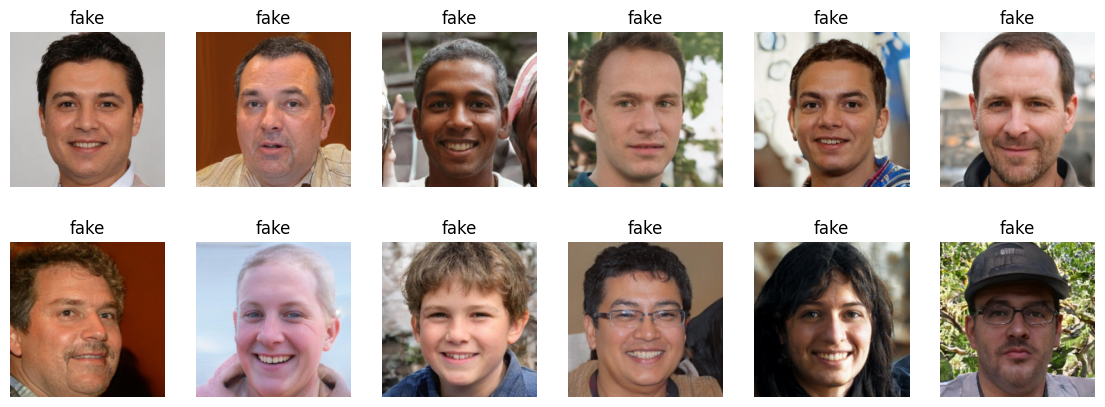

In [9]:
import matplotlib.pyplot as plt
import numpy as np

x, y = next(iter(val_loader))
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    idx = i * 5
    img = x[idx].permute(1, 2, 0).numpy() * std + mean
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(classes[y[idx]])
    ax.axis("off")
plt.show()

In [10]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

device = "cuda"
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze everything, then unfreeze only the last block (layer4)
for p in model.parameters():
    p.requires_grad = False
for p in model.layer4.parameters():
    p.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 2)  # new head: fake vs real
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(),     "lr": 1e-3},
], weight_decay=1e-4)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]

Trainable params: 8,394,754


In [11]:
import time

EPOCHS   = 5
SAVE_DIR = "/content/deepfake-detector"
BEST_PATH = f"{SAVE_DIR}/best_model.pth"
os.makedirs(SAVE_DIR, exist_ok=True)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler("cuda")
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val = 0.0

def run_epoch(loader, train):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.amp.autocast("cuda"):   # mixed precision = faster on T4
                out = model(x)
                loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)
    scheduler.step()

    for k, v in zip(history, [tr_loss, tr_acc, va_loss, va_acc]):
        history[k].append(v)

    saved = ""
    if va_acc > best_val:
        best_val = va_acc
        torch.save({"model_state": model.state_dict(),
                    "class_to_idx": train_full.class_to_idx,
                    "epoch": epoch, "val_acc": va_acc}, BEST_PATH)
        saved = "  <- saved best"

    print(f"Epoch {epoch}/{EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.3f} | {time.time()-start:.0f}s{saved}")

print(f"Best val accuracy: {best_val:.3f} | saved to {BEST_PATH}")

Epoch 1/5 | train loss 0.2993 acc 0.869 | val loss 0.1968 acc 0.916 | 137s  <- saved best
Epoch 2/5 | train loss 0.1480 acc 0.940 | val loss 0.1292 acc 0.950 | 119s  <- saved best
Epoch 3/5 | train loss 0.0932 acc 0.963 | val loss 0.1162 acc 0.953 | 119s  <- saved best
Epoch 4/5 | train loss 0.0565 acc 0.979 | val loss 0.1095 acc 0.959 | 121s  <- saved best
Epoch 5/5 | train loss 0.0436 acc 0.984 | val loss 0.0899 acc 0.966 | 119s  <- saved best
Best val accuracy: 0.966 | saved to /content/deepfake-detector/best_model.pth


              precision    recall  f1-score   support

        fake      0.967     0.965     0.966      2000
        real      0.965     0.968     0.966      2000

    accuracy                          0.966      4000
   macro avg      0.966     0.966     0.966      4000
weighted avg      0.966     0.966     0.966      4000



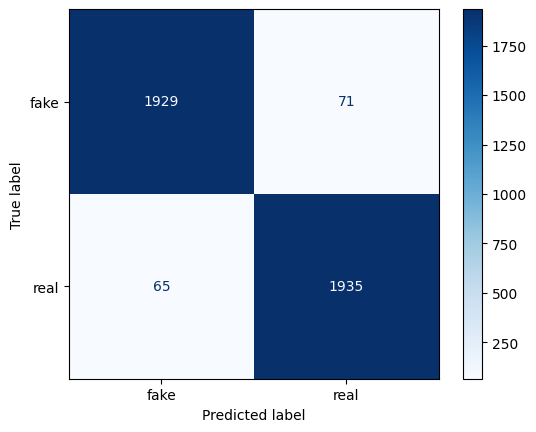

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

ckpt = torch.load(BEST_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        all_preds += out.argmax(1).cpu().tolist()
        all_labels += y.tolist()

print(classification_report(all_labels, all_preds, target_names=classes, digits=3))
ConfusionMatrixDisplay(confusion_matrix(all_labels, all_preds), display_labels=classes).plot(cmap="Blues")
plt.show()

              precision    recall  f1-score   support

        fake      0.967     0.965     0.966      2000
        real      0.965     0.968     0.966      2000

    accuracy                          0.966      4000
   macro avg      0.966     0.966     0.966      4000
weighted avg      0.966     0.966     0.966      4000



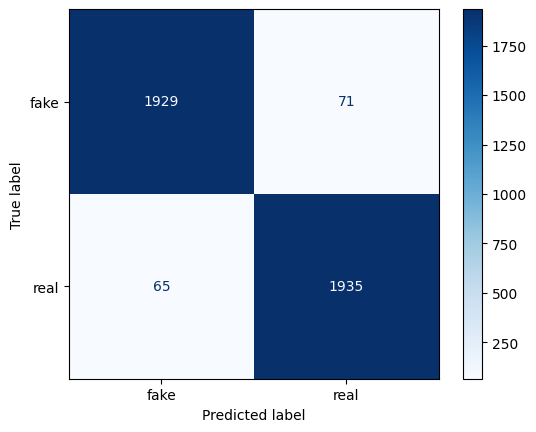

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

ckpt = torch.load(BEST_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        all_preds += out.argmax(1).cpu().tolist()
        all_labels += y.tolist()

print(classification_report(all_labels, all_preds, target_names=classes, digits=3))
ConfusionMatrixDisplay(confusion_matrix(all_labels, all_preds), display_labels=classes).plot(cmap="Blues")
plt.show()

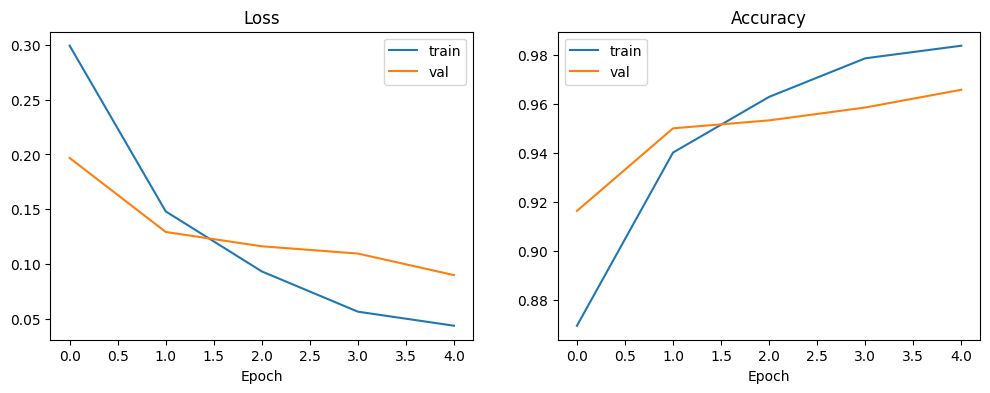

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history["train_acc"], label="train"); ax2.plot(history["val_acc"], label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

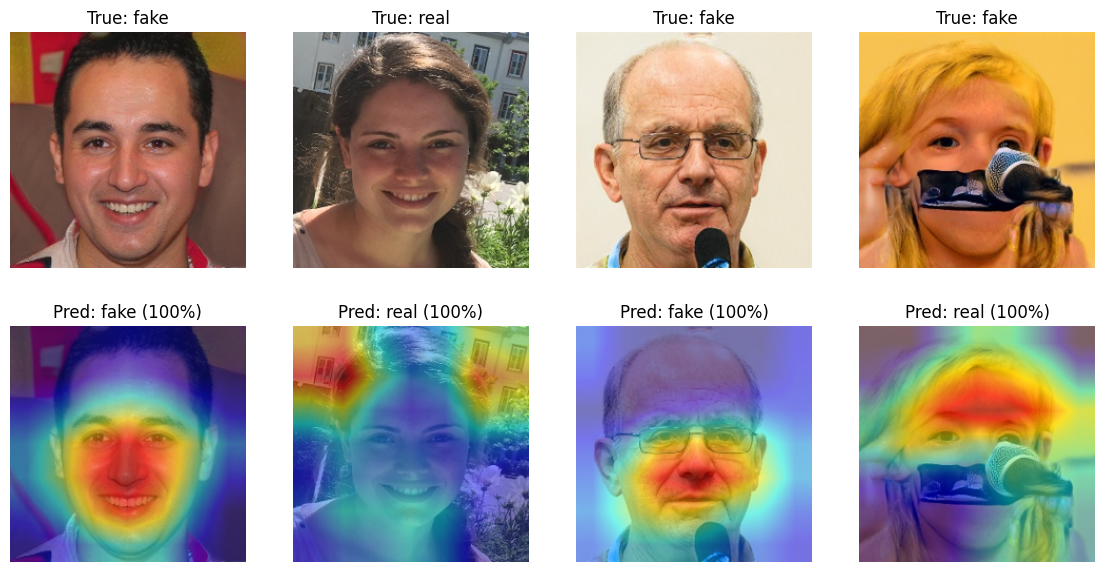

In [15]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
samples = random.sample(test_full.samples, 4)
for col, (img_path, label) in enumerate(samples):
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    rgb = np.array(img).astype(np.float32) / 255
    inp = eval_tf(img).unsqueeze(0).to(device)

    probs = torch.softmax(model(inp), dim=1)[0]
    pred = probs.argmax().item()
    heat = cam(input_tensor=inp, targets=[ClassifierOutputTarget(pred)])[0]

    axes[0, col].imshow(img); axes[0, col].set_title(f"True: {classes[label]}")
    axes[1, col].imshow(show_cam_on_image(rgb, heat, use_rgb=True))
    axes[1, col].set_title(f"Pred: {classes[pred]} ({probs[pred]:.0%})")
    axes[0, col].axis("off"); axes[1, col].axis("off")

plt.savefig(f"{SAVE_DIR}/gradcam_examples.png", dpi=120, bbox_inches="tight")
plt.show()

In [16]:
from google.colab import files
files.download(f"{SAVE_DIR}/best_model.pth")
files.download(f"{SAVE_DIR}/training_curves.png")
files.download(f"{SAVE_DIR}/gradcam_examples.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>